# 05. LangGraph 챗봇 구축

> 앞서 배운 StateGraph 개념을 합쳐 첫 챗봇을 만들어요. `add_messages` 리듀서로 대화 이력을 누적하고 `stream()` 으로 실시간 응답까지 출력하는 흐름을 한 번에 경험해요.

## 학습 목표

이 노트북을 마치면 다음을 할 수 있어요:

1. `TypedDict`와 `Annotated`를 사용해서 LangGraph 상태(State)를 정의할 수 있어요
2. `add_messages` 리듀서가 메시지를 '덮어쓰지 않고 추가'하는 원리를 설명할 수 있어요
3. StateGraph에 노드(Node)와 엣지(Edge)를 추가하고 `compile()`로 실행 가능한 그래프를 만들 수 있어요
4. `stream()` 메서드로 챗봇의 응답을 실시간으로 출력할 수 있어요

## 사전 지식

- 이전 노트북 `04-StateGraph-Basics.ipynb`에서 배운 StateGraph, State, Node, Edge, START/END 개념
- `init_chat_model()` 기반 LLM 초기화 방법 (Part 2 - 02-Models 참고)
- Python `TypedDict`와 `Annotated` 타입 힌트 기본 이해

## LangGraph 챗봇의 구조

이전 노트북에서 StateGraph, Node, Edge의 기본 구성 요소를 배웠어요. 이제 그 구성 요소에 **실제 LLM을 연결**해서 대화가 가능한 챗봇을 만들어볼 거예요. LangGraph로 챗봇을 만드는 건 의외로 간단해요. 핵심은 **상태(State)에 메시지를 쌓아가는 구조**예요.

사용자 질문이 들어오면 `chatbot` 노드가 LLM을 호출하고, 응답을 상태에 추가해요. `add_messages` 리듀서 덕분에 메시지 히스토리가 자동으로 누적됩니다.

> 🔑 **핵심 개념**: LangGraph의 챗봇은 '상태 기계(State Machine)'예요. 상태(State)를 공유하는 노드들이 순서에 따라 실행되면서 대화가 진행돼요.

### 전체 아키텍처

```mermaid
flowchart TD
    U(["사용자 입력<br>User Input"]) --> S
    S(["__start__"]) --> C
    C["chatbot 노드<br>LLM 호출"] --> E
    E(["__end__"]) --> R(["응답 출력<br>Response"])

    classDef input fill:#d4edda,stroke:#28a745,color:#155724
    classDef process fill:#cce5ff,stroke:#007bff,color:#004085
    classDef output fill:#fff3cd,stroke:#ffc107,color:#856404

    class U,S input
    class C process
    class E,R output
```

### 핵심 구성 요소

| 구성 요소 | 역할 | 코드 |
|-----------|------|------|
| **State** | 그래프 전체가 공유하는 데이터 구조 | `class State(TypedDict)` |
| **add_messages** | 메시지 추가 전용 리듀서 | `Annotated[list, add_messages]` |
| **chatbot 노드** | LLM을 호출하는 핵심 함수 | `def chatbot(state: State)` |
| **StateGraph** | 전체 그래프 빌더 | `StateGraph(State)` |
| **compile()** | 그래프를 실행 가능 형태로 변환 | `graph_builder.compile()` |

## 환경 설정

In [1]:
# API 키를 환경변수로 관리하기 위한 설정
from dotenv import load_dotenv

# .env 파일에서 API 키 로드
load_dotenv(override=True)

True

In [2]:
# LangSmith 추적 설정 (선택사항 - 실행 흐름을 LangSmith에서 시각화할 수 있어요)
import os

# LangSmith 추적 활성화: "true"로 설정하면 실행 로그가 LangSmith에 기록돼요
# os.environ["LANGCHAIN_TRACING_V2"] = "true"
# os.environ["LANGCHAIN_PROJECT"] = "LangGraph-V1-Tutorial-05-ChatBot"

## 1. 챗봇을 7단계로 구축하기

LangGraph 챗봇을 구축하는 과정을 7단계로 나누어 살펴볼게요. 각 단계는 State, Node, Edge, Graph와 직접 연결되어 있으니 순서대로 따라가며 이해하는 걸 권장해요.

### STEP 1. 상태(State) 정의

LangGraph에서 **상태(State)**는 그래프의 모든 노드가 공유하는 데이터 구조예요. `TypedDict`를 사용해서 정의하며, 각 노드는 이 상태를 읽고 업데이트할 수 있어요.

`messages` 필드는 `Annotated` 타입과 `add_messages` 리듀서를 사용해서 정의해요.

> 🔑 **핵심 개념**: `add_messages`는 일반 할당(덮어쓰기)이 아니라 **리듀서(Reducer)** 패턴이에요. 새 메시지가 기존 목록에 '추가'되므로, 대화 히스토리가 자동으로 쌓여요. `messages = [새 메시지]`가 아니라 `messages += [새 메시지]`처럼 동작한다고 이해하면 돼요.

> ⚠️ **자주 하는 실수**: `add_messages` 없이 `messages: list` 로만 정의하면, 노드가 반환하는 새 메시지가 기존 메시지를 덮어써요. 이전 대화 내용이 사라지는 버그가 생기므로 반드시 리듀서를 지정해야 해요.

In [3]:
# LangGraph 핵심 그래프 구성 요소를 가져와요
from typing import Annotated, TypedDict
from langgraph.graph import StateGraph, START, END
from langgraph.graph import add_messages  # 메시지 누적 리듀서


# 챗봇의 상태 정의
# TypedDict: 딕셔너리에 타입 힌트를 추가해서 IDE 자동완성과 타입 검사를 활용해요
class State(TypedDict):
    # messages: 대화 메시지를 저장하는 리스트
    # Annotated[list, add_messages]: add_messages 리듀서를 적용해서 메시지를 추가(append) 방식으로 관리해요
    messages: Annotated[list, add_messages]


# State 정의 완료!
print(f"State 필드: {State.__annotations__}")

State 필드: {'messages': typing.Annotated[list, <function _add_messages_wrapper.<locals>._add_messages at 0x1154461f0>]}


### STEP 2. 노드(Node) 정의

노드(Node)는 그래프에서 실제 작업을 수행하는 단위예요. 보통 Python 함수로 정의하며, 현재 상태(State)를 입력으로 받아 처리하고 업데이트된 상태를 반환해요.

챗봇 노드 함수는 상태에서 메시지를 읽어 LLM에 전달하고, LLM의 응답을 새 메시지로 반환해요. 반환된 메시지는 `add_messages` 리듀서에 의해 기존 메시지 목록에 자동으로 추가돼요.

> 💡 **실무 팁**: `init_chat_model("openai:gpt-4o-mini")`는 LangChain V1에서 권장하는 모델 초기화 방식이에요. 프로바이더 접두어(`openai:`, `anthropic:`, `google_genai:`)를 붙이면 동일한 코드로 다양한 모델을 교체해서 사용할 수 있어요.

In [4]:
# LangChain V1의 통합 모델 초기화 함수를 가져와요
from langchain.chat_models import init_chat_model

# ---------------------------------------------------
# 모델 초기화
# ---------------------------------------------------
# 기본 모델: gpt-4o-mini (비용 효율적, 학습용으로 적합해요)
# 다른 모델로 교체할 때: "anthropic:claude-sonnet-4-5" 또는 "google_genai:gemini-2.0-flash"
llm = init_chat_model("openai:gpt-4o-mini")


# 챗봇 노드 함수 정의
def chatbot(state: State):
    """챗봇 노드 함수

    현재 상태의 메시지를 LLM에 전달하고,
    LLM의 응답을 새 메시지로 추가하여 반환해요.

    Args:
        state: 현재 그래프 상태 (messages 키를 포함)

    Returns:
        업데이트된 상태 딕셔너리: {"messages": [AI 응답]}
    """
    # state["messages"]: 지금까지의 모든 대화 메시지 리스트
    # llm.invoke(messages): LLM에 메시지를 전달하고 응답을 받아요
    # 반환값 {"messages": [...]}은 add_messages 리듀서에 의해 기존 메시지에 추가돼요
    return {"messages": [llm.invoke(state["messages"])]}


# LLM과 chatbot 노드 정의 완료!

### STEP 3. 그래프(Graph) 정의와 노드 추가

`StateGraph`는 LangGraph의 핵심 클래스로, 상태 기반 워크플로우를 정의해요. 정의한 `State` 타입을 인자로 전달해서 그래프 빌더를 생성해요.

`add_node()` 메서드로 그래프에 노드를 추가해요. 첫 번째 인자는 노드 이름(문자열)이고, 두 번째 인자는 실행될 함수예요.

> 🎯 **강의 포인트**: `graph_builder = StateGraph(State)` 이 한 줄에서 `State`를 넘기는 이유를 설명해야 해요. 그래프가 어떤 데이터 구조를 공유할지 미리 알려주는 거예요. 노드들은 이 State 스키마를 따라야만 데이터를 교환할 수 있어요.

In [5]:
# ---------------------------------------------------
# 그래프 빌더 생성
# ---------------------------------------------------
# StateGraph(State): State 스키마를 기반으로 하는 그래프 빌더를 만들어요
graph_builder = StateGraph(State)

# 그래프에 chatbot 노드 추가
# 인자 1: 노드 이름 (문자열 - 그래프에서 이 이름으로 참조돼요)
# 인자 2: 실행될 함수 (State를 받아 업데이트된 State를 반환하는 함수)
graph_builder.add_node("chatbot", chatbot)

# StateGraph 생성 및 chatbot 노드 추가 완료!

### STEP 4. 엣지(Edge) 추가

엣지(Edge)는 노드와 노드를 연결해서 그래프의 실행 흐름을 정의해요. LangGraph는 `START`와 `END` 두 가지 특수 노드를 제공해요.

- `START`: 그래프 실행의 진입점 — 처음으로 실행될 노드를 지정해요
- `END`: 그래프 실행의 종료점 — 더 이상 실행할 노드가 없음을 나타내요

> 🎯 **강의 포인트**: `START → chatbot → END` 흐름을 칠판에 그려가며 설명하면 효과적이에요. 지금은 단순하지만, 나중에 조건부 엣지(conditional edge)를 추가하면 더 복잡한 분기 로직을 만들 수 있어요. (다음 노트북에서 다뤄요!)

In [6]:
# ---------------------------------------------------
# 엣지 추가: 그래프 실행 흐름 정의
# ---------------------------------------------------

# START → chatbot: 그래프가 시작되면 chatbot 노드를 실행해요
graph_builder.add_edge(START, "chatbot")

# chatbot → END: chatbot 노드 실행이 끝나면 그래프를 종료해요
graph_builder.add_edge("chatbot", END)

# 엣지 추가 완료: START → chatbot → END

### STEP 5. 그래프 컴파일(compile)

`StateGraph`를 정의한 후에는 반드시 `compile()` 메서드를 호출해서 실행 가능한 형태로 변환해야 해요. 컴파일 과정에서 노드 간 연결이 검증되고 실행 순서가 결정돼요.

`compile()`을 건물의 **준공 검사**에 비유할 수 있어요. 설계도(StateGraph)를 그리고 자재를 배치(add_node, add_edge)한 뒤, 모든 연결이 올바른지 최종 점검하는 단계예요. 준공 검사를 통과해야 건물에 입주(invoke/stream)할 수 있는 것처럼, `compile()` 없이는 그래프를 실행할 수 없어요.

컴파일된 그래프는 `invoke()` 또는 `stream()` 메서드를 통해 실행할 수 있어요.

> ⚠️ **자주 하는 실수**: `compile()` 을 호출하지 않고 `graph_builder.invoke()`를 시도하면 오류가 발생해요. `StateGraph`는 빌더(Builder) 패턴으로, 반드시 `compile()` 후 실행해야 해요.

In [7]:
# ---------------------------------------------------
# 그래프 컴파일
# ---------------------------------------------------
# compile(): StateGraph 빌더를 실행 가능한 CompiledGraph로 변환해요
# 이 단계에서 노드 연결 검증, 실행 순서 결정 등이 이루어져요
graph = graph_builder.compile()

print(f"그래프 컴파일 완료!")
print(f"그래프 타입: {type(graph)}")

그래프 컴파일 완료!
그래프 타입: <class 'langgraph.graph.state.CompiledStateGraph'>


### STEP 6. 그래프 시각화

컴파일된 그래프를 시각화해서 노드 간 연결 관계와 실행 흐름을 직관적으로 확인해볼게요.

복잡한 그래프를 디버깅하거나 구조를 검토할 때 매우 유용한 기능이에요.

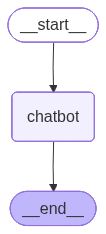

In [8]:
# 그래프 흐름: START → chatbot → END
# chatbot 노드: LLM이 사용자 메시지를 받아 응답을 생성해요
# IPython 디스플레이 도구 가져오기
from IPython.display import Image, display

# ---------------------------------------------------
# 그래프 시각화
# ---------------------------------------------------
# get_graph().draw_mermaid_png(): Mermaid 형식으로 그래프를 PNG 이미지로 변환해요
display(Image(graph.get_graph().draw_mermaid_png()))

### STEP 7. 그래프 실행

이제 챗봇을 실행해볼게요! `stream()` 메서드를 사용하면 응답을 실시간으로 받을 수 있어요.

입력은 딕셔너리 형태로 전달하며, `messages` 키에 사용자 메시지 튜플 `("user", 질문내용)`을 리스트로 감싸서 전달해요.

> 🎯 **강의 포인트**: `stream_mode="updates"` 옵션을 강조해야 해요. 이 옵션은 각 노드가 실행될 때마다 업데이트된 내용만 반환해요. 반면 `stream_mode="values"`는 전체 상태를 반환해요. 두 모드를 비교해서 보여주면 학생들이 차이를 쉽게 이해할 수 있어요.

In [9]:
# ---------------------------------------------------
# 그래프 실행 - stream 모드 (updates)
# ---------------------------------------------------
question = "서울의 유명한 맛집 TOP 5를 추천해줘"

# 입력 메시지 구성: (역할, 내용) 튜플 형식으로 전달해요
# LangGraph가 내부적으로 HumanMessage로 변환해요
inputs = {"messages": [("user", question)]}

print(f"질문: {question}")
# ==================================================

# stream(): 그래프를 실행하며 각 노드의 업데이트를 스트리밍으로 반환해요
# stream_mode="updates": 각 노드가 반환한 업데이트 내용만 받아요
for chunk in graph.stream(inputs, stream_mode="updates"):
    for node_name, node_output in chunk.items():
        print(f"\n--- 노드: {node_name} ---")
        # 메시지가 있으면 pretty_print()로 보기 좋게 출력해요
        if "messages" in node_output:
            for msg in node_output["messages"]:
                msg.pretty_print()

질문: 서울의 유명한 맛집 TOP 5를 추천해줘

--- 노드: chatbot ---
================================== Ai Message ==================================

서울에는 다양한 맛집이 많이 있습니다. 아래는 서울에서 유명한 맛집 TOP 5를 추천드립니다.

1. **광화문 국밥**
   - 주소: 서울 종로구 세종대로 107
   - 추천 메뉴: 소머리국밥
   - 설명: 깊고 진한 국물 맛이 일품인 소머리국밥으로 유명하며, 많은 사람들이 찾는 전통 국밥집입니다.

2. **이태원 부대찌개**
   - 주소: 서울 용산구 이태원로 198
   - 추천 메뉴: 부대찌개
   - 설명: 다양한 재료가 듬뿍 들어간 부대찌개로, 매콤한 맛이 일품입니다. 친구들과 함께 공유하기 좋은 메뉴입니다.

3. **세븐스프링스**
   - 주소: 서울 강남구 논현로 713
   - 추천 메뉴: 샐러드바
   - 설명: 신선한 재료로 만들어진 다양한 샐러드를 무한리필로 즐길 수 있는 곳입니다. 건강식이 필요한 분들에게 추천합니다.

4. **마포 갈매기**
   - 주소: 서울 마포구 마포대로 4길 12
   - 추천 메뉴: 갈매기살
   - 설명: 고소하고 쫄깃한 갈매기살을 숯불로 구워 먹을 수 있는 인기 있는 고기집입니다. 다양한 밑반찬과 함께 즐길 수 있습니다.

5. **홍대장어**
   - 주소: 서울 마포구 홍익로 22
   - 추천 메뉴: 장어구이
   - 설명: 신선한 장어를 사용하는 장어 전문점으로, 숯불에 구워낸 장어는 껍질이 바삭하고 속은 부드럽습니다.

위의 맛집들은 각기 다른 매력을 가지고 있으니, 기회가 된다면 방문해 보시길 추천드립니다!


## 2. add_messages 리듀서 심층 이해

챗봇의 핵심인 `add_messages` 리듀서가 실제로 어떻게 작동하는지 직접 확인해볼게요.

> 🔑 **핵심 개념**: 일반적인 딕셔너리 업데이트는 기존 값을 **덮어써요**(`state["messages"] = 새 메시지`). 하지만 `add_messages` 리듀서는 새 메시지를 기존 목록에 **추가해요**(`state["messages"] += [새 메시지]`). 이 차이가 대화 히스토리 유지의 핵심이에요.

### 비유: 칠판 vs 노트

리듀서가 없는 일반 필드는 **칠판**과 같아요. 새로운 내용을 쓰면 이전 내용이 지워져요. 반면 `add_messages` 리듀서가 적용된 필드는 **노트**와 같아요. 새로운 내용을 쓰면 이전 페이지 뒤에 이어서 기록돼요. 대화 히스토리는 이전 내용이 사라지면 안 되니까, 반드시 "노트" 방식(`add_messages`)을 써야 해요.

| 방식 | 비유 | 동작 | 예시 |
|------|------|------|------|
| 일반 필드 (리듀서 없음) | 칠판 | 덮어쓰기 | `messages = [새 메시지]` (이전 대화 사라짐) |
| `add_messages` 리듀서 | 노트 | 이어쓰기 | `messages += [새 메시지]` (이전 대화 유지) |

In [10]:
# ---------------------------------------------------
# add_messages 리듀서 동작 확인
# ---------------------------------------------------
# invoke()로 실행하면 최종 상태 전체를 반환해요
result = graph.invoke({"messages": [("user", "파이썬이란 무엇인가요? 한 문장으로 답해주세요.")]})

# 최종 상태의 messages 목록:
print(f"총 메시지 수: {len(result['messages'])}개")
print()

# 메시지 목록을 순서대로 출력해요
for i, msg in enumerate(result["messages"]):
    print(f"[{i+1}] 타입: {msg.type}")
    # 내용이 길면 200자까지만 출력해요
    content_preview = msg.content[:200] if len(msg.content) > 200 else msg.content
    print(f"    내용: {content_preview}")
    print()

총 메시지 수: 2개

[1] 타입: human
    내용: 파이썬이란 무엇인가요? 한 문장으로 답해주세요.

[2] 타입: ai
    내용: 파이썬은 간결하고 읽기 쉬운 문법을 가진 고급 프로그래밍 언어로, 다양한 분야에서 사용됩니다.



## 3. 스트리밍 출력 모드 비교

LangGraph의 `stream()` 메서드는 두 가지 주요 모드를 지원해요. 각각의 차이를 이해하면 필요에 맞게 선택할 수 있어요.

| 모드 | 반환 내용 | 사용 시점 |
|------|-----------|----------|
| `stream_mode="updates"` | 각 노드가 반환한 **업데이트 내용만** | 어떤 노드가 무엇을 변경했는지 추적할 때 |
| `stream_mode="values"` | 각 단계 후의 **전체 상태** | 실행 중간 상태를 전부 확인할 때 |

> 💡 **실무 팁**: 프로덕션 환경에서는 `stream_mode="updates"`가 더 효율적이에요. 변경된 부분만 전송하므로 네트워크 트래픽을 줄일 수 있어요.

> ⚠️ **자주 하는 실수**: `stream_mode="values"`로 전체 상태를 받을 때, 메시지가 많아지면 매번 전체 히스토리가 반복 전송돼요. 대화가 길어지면 `"updates"` 모드로 전환하는 것이 좋아요.

In [ ]:
# ---------------------------------------------------
# stream_mode="values" 방식 비교
# ---------------------------------------------------
# [stream_mode='values'] 전체 상태 스트리밍
# ==================================================

# stream_mode="values": 각 노드 실행 후 전체 State를 반환해요
for snapshot in graph.stream( {"messages": [("user", "LangGraph가 뭔지 두 줄로 설명해줘")]}, stream_mode="values"):
    # snapshot은 현재 시점의 전체 State 딕셔너리예요
    print(f"\n현재 상태 messages 수: {len(snapshot['messages'])}개")
    # 마지막 메시지만 출력해요
    snapshot["messages"][-1].pretty_print()


현재 상태 messages 수: 1개
================================ Human Message =================================

LangGraph가 뭔지 두 줄로 설명해줘

현재 상태 messages 수: 2개
================================== Ai Message ==================================

LangGraph는 자연어 처리(NLP)와 그래프 기반 데이터 구조를 결합하여 언어 이해와 생성 작업을 수행하는 모델이다. 이를 통해 언어의 의미와 구조를 효과적으로 분석하고 처리할 수 있는 방법을 제공한다.


## 4. 전체 코드 통합

앞서 7단계로 나누어 살펴본 코드를 하나의 셀로 정리했어요. 처음부터 다시 실행하거나 새 환경에서 시작할 때 이 셀을 사용하면 돼요.

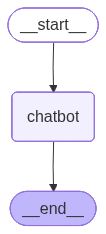

질문: 인공지능이란 무엇인가요? 간단하게 설명해주세요.

--- 노드: chatbot ---
================================== Ai Message ==================================

인공지능(AI)은 인간의 지능을 모방하여 학습, 추론, 문제 해결 및 의사 결정을 수행할 수 있는 시스템이나 기술을 말합니다. AI는 데이터와 알고리즘을 사용하여 패턴을 인식하고, 정보를 처리하며, 스스로 개선할 수 있는 능력을 가지고 있습니다. 일반적으로 머신러닝, 딥러닝, 자연어 처리와 같은 기술들이 포함됩니다. AI는 다양한 분야에서 활용되고 있으며, 예를 들어 자율주행차, 음성 인식, 의료 진단 등에 적용됩니다.


In [12]:
# ---------------------------------------------------
# LangGraph 챗봇 전체 코드 (통합본)
# ---------------------------------------------------
from typing import Annotated, TypedDict
from langchain.chat_models import init_chat_model
from langgraph.graph import StateGraph, START, END
from langgraph.graph import add_messages
from IPython.display import Image, display


# STEP 1. 상태(State) 정의
class State(TypedDict):
    # add_messages 리듀서: 메시지를 덮어쓰지 않고 추가(append)해요
    messages: Annotated[list, add_messages]


# STEP 2. 노드(Node) 정의
# 기본 모델: gpt-4o-mini
llm = init_chat_model("openai:gpt-4o-mini")


def chatbot(state: State):
    """챗봇 노드: 현재 메시지를 LLM에 전달하고 응답을 반환해요"""
    return {"messages": [llm.invoke(state["messages"])]}


# STEP 3. 그래프 빌더 생성 및 노드 추가
graph_builder = StateGraph(State)
graph_builder.add_node("chatbot", chatbot)

# STEP 4. 엣지 추가
graph_builder.add_edge(START, "chatbot")  # 시작 → chatbot
graph_builder.add_edge("chatbot", END)    # chatbot → 종료

# STEP 5. 컴파일
graph = graph_builder.compile()

# STEP 6. 시각화
# 그래프 흐름: START → chatbot → END
# chatbot 노드: LLM이 사용자 메시지를 받아 응답을 생성해요
display(Image(graph.get_graph().draw_mermaid_png()))

# STEP 7. 실행
question = "인공지능이란 무엇인가요? 간단하게 설명해주세요."

print(f"질문: {question}")
# ==================================================

for chunk in graph.stream({"messages": [("user", question)]}, stream_mode="updates"):
    for node_name, node_output in chunk.items():
        print(f"\n--- 노드: {node_name} ---")
        if "messages" in node_output:
            for msg in node_output["messages"]:
                msg.pretty_print()

## 5. 실습: 나만의 챗봇 만들기

아래 TODO 블록에서 시스템 프롬프트를 추가해서 특정 역할을 가진 챗봇을 만들어보세요.

`SystemMessage`를 메시지 목록에 추가하면 챗봇의 역할을 지정할 수 있어요.

In [13]:
# LangChain 메시지 타입 가져오기
from langchain.messages import SystemMessage

# ============================================================
# TODO: 아래에서 시스템 프롬프트를 수정해서 나만의 챗봇을 만들어보세요!
# 힌트: SYSTEM_PROMPT 문자열을 원하는 역할로 변경하면 돼요
#       예: "당신은 친절한 한국 역사 선생님이에요. 모든 답변은 한국어로 해주세요."
#       예: "당신은 파이썬 코딩 튜터예요. 코드 예제를 많이 사용해서 설명해주세요."
# 예상 결과: 시스템 프롬프트에 정의된 역할대로 챗봇이 응답해요
# ============================================================
SYSTEM_PROMPT = "당신은 유머러스한 한국어 과학 선생님이에요. 어려운 과학 개념을 재미있는 비유로 설명해주세요."

# TODO: 질문도 원하는 내용으로 바꿔보세요!
USER_QUESTION = "블랙홀이 뭔가요?"
# ============================================================


# 시스템 프롬프트를 포함한 메시지 구성
# SystemMessage: LLM에게 역할과 행동 방식을 지정하는 메시지예요
messages = [
    SystemMessage(content=SYSTEM_PROMPT),  # 시스템 프롬프트 (역할 지정)
    ("user", USER_QUESTION),               # 사용자 질문
]

print(f"시스템 프롬프트: {SYSTEM_PROMPT[:50]}...")
print(f"질문: {USER_QUESTION}")
# ==================================================

# 그래프 실행
for chunk in graph.stream({"messages": messages}, stream_mode="updates"):
    for node_name, node_output in chunk.items():
        print(f"\n--- 노드: {node_name} ---")
        if "messages" in node_output:
            for msg in node_output["messages"]:
                msg.pretty_print()

시스템 프롬프트: 당신은 유머러스한 한국어 과학 선생님이에요. 어려운 과학 개념을 재미있는 비유로 설명해주세...
질문: 블랙홀이 뭔가요?

--- 노드: chatbot ---
================================== Ai Message ==================================

아하! 블랙홀, 마치 우주의 큰 빨래통 같아요! 상상해 보세요, 우리가 빨래를 하는 통이 잘 돌려지면 세탁물 속의 먼지와 때가 다 빨려 들어가죠? 블랙홀도 비슷해요! 우주에서 별들이 너무 많이 뭉치면서 중력이 슈퍼 강해져서 주변의 모든 것을 쏙쏙 빨아들이는 거랍니다.

그런데 블랙홀은 빨래통과 달리 정체불명의 세탁물이 아니라, 아예 빛조차도 탈출할 수 없는 신비한 곳이에요. 그래서 직접 보지는 못하지만, 주변에서 일어나는 일이 우리에게 블랙홀의 존재를 알려주는 거죠.

이런 블랙홀은 우주를 여행하는 고무 나팔 같아요. 고무 나팔처럼 제법 큰데, 소리를 내지 않으면 조용히 존재하는 것처럼 주변의 모든 것들을 흡수하면서도 그 모습은 보이지 않으니까요. 무섭기도 하고, 신기하기도 한 우주의 빨래통, 블랙홀이란 놈이랍니다!


## 핵심 요약

이 노트북에서 다음 내용을 배웠어요:

- **State 정의**: `TypedDict`와 `Annotated[list, add_messages]`를 사용해서 메시지 누적 상태를 정의했어요
- **add_messages 리듀서**: 새 메시지가 기존 메시지를 덮어쓰지 않고 추가(append)되어 대화 히스토리가 유지돼요
- **chatbot 노드**: `state["messages"]`를 LLM에 전달하고 응답을 반환하는 함수로 노드를 정의했어요
- **그래프 구성**: `add_node()`, `add_edge()`, `compile()` 순서로 실행 가능한 StateGraph를 만들었어요
- **stream() 실행**: `stream_mode="updates"`와 `"values"` 두 가지 스트리밍 모드의 차이를 이해했어요
- **시스템 프롬프트**: `SystemMessage`를 메시지 목록에 추가하면 챗봇의 역할을 지정할 수 있어요

## 다음 노트북 예고

다음 `06-Tools-Integration.ipynb`에서는 **Tool Binding, ToolNode, tools_condition**을 배워요.

지금까지 만든 챗봇은 LLM이 아는 지식만 대답할 수 있었어요. 다음 노트북에서는 웹 검색, 계산기 같은 외부 도구를 챗봇에 연결해서 실제 세계와 상호작용하는 에이전트를 만들어볼 거예요!